# CloudSense — Cloud Resource Usage Analytics
**Apoorvan A | 23BCE0755 | VIT Vellore**

Run this notebook on Google Colab (Runtime → Change runtime type → T4 GPU).

All dependencies are pre-installed on Colab. Just run all cells in order.

In [12]:
from google.colab import files
files.upload()


KeyboardInterrupt: 

In [2]:
!unzip CloudSense_v2.zip

Archive:  CloudSense_v2.zip
   creating: CloudSense_v2/
   creating: CloudSense_v2/.venv/
   creating: CloudSense_v2/.venv/Include/
   creating: CloudSense_v2/.venv/Lib/
   creating: CloudSense_v2/.venv/Lib/site-packages/
  inflating: CloudSense_v2/.venv/pyvenv.cfg  
   creating: CloudSense_v2/.venv/Scripts/
  inflating: CloudSense_v2/.venv/Scripts/python.exe  
  inflating: CloudSense_v2/.venv/Scripts/pythonw.exe  
   creating: CloudSense_v2/data/
   creating: CloudSense_v2/figures/
  inflating: CloudSense_v2/main.py   
  inflating: CloudSense_v2/requirements.txt  
   creating: CloudSense_v2/results/
  inflating: CloudSense_v2/RESUME_BULLET.txt  
  inflating: CloudSense_v2/Run_on_Colab.ipynb  
   creating: CloudSense_v2/src/
  inflating: CloudSense_v2/src/data_loader.py  
  inflating: CloudSense_v2/src/models_torch.py  
  inflating: CloudSense_v2/src/train_evaluate.py  


In [8]:
!ls


data	 main.py	   results	      Run_on_Colab.ipynb
figures  requirements.txt  RESUME_BULLET.txt  src


In [4]:
# ── Upload project files or clone from your repo ──────────────────────────
# Option A: Upload the CloudSense_v2 folder as a ZIP and unzip it
# from google.colab import files
# files.upload()   # upload CloudSense_v2.zip
# !unzip CloudSense_v2.zip

# Option B: If you push to GitHub, clone it:
# !git clone https://github.com/YOUR_USERNAME/cloudsense.git
# %cd cloudsense

# For now, assume files are already uploaded to /content/CloudSense_v2
%cd /content/CloudSense_v2
!ls

/content/CloudSense_v2
data	 main.py	   results	      Run_on_Colab.ipynb
figures  requirements.txt  RESUME_BULLET.txt  src


In [5]:
# ── Install any missing packages (most are pre-installed on Colab) ─────────
!pip install -q scikit-learn torch pandas numpy matplotlib seaborn requests
import torch
print(f'PyTorch: {torch.__version__}  |  CUDA: {torch.cuda.is_available()}')

PyTorch: 2.10.0+cu128  |  CUDA: True


In [10]:
!sed -i 's/, verbose=False//g' src/train_evaluate.py


In [13]:
# ── Run the full experiment ────────────────────────────────────────────────
# This will:
#   1. Download the real AWS EC2 dataset from Numenta NAB
#   2. Train all 5 models (LSTM, CNN-LSTM, BiLSTM, Transformer, CEEMDAN+CNN-BiLSTM)
#   3. Evaluate on test set
#   4. Save all figures and metrics
!python main.py


  CloudSense  |  Cloud Resource Usage Analytics
  Apoorvan A  |  23BCE0755  |  VIT Vellore
  Device: cuda

[1/4] Loading dataset …
  [Cached]     ec2_cpu_utilization_24ae8d.csv
  [Cached]     ec2_cpu_utilization_5f5533.csv
  [Cached]     ec2_cpu_utilization_825cc2.csv
  [Cached]     ec2_cpu_utilization_ac20cd.csv
  [Dataset] 16,128 samples | mean=43.9%  std=33.6%  min=2.0%  max=98.0%

[2/4] Training models …
/content/CloudSense_v2/src/models_torch.py:183: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

  → LSTM (Bansal 2023)
    Epoch  20 | train=0.00686  val=0.06276
    Epoch  40 | train=0.00627  val=0.05617
    Epoch  60 | train=0.00577  val=0.05392
    Epoch  80 | train=0.00573  val=0.05296
    Epoch 100 | train=0.00566  val=0.05278
    Epoch 120 | train=0.00558  val=0.05265
    Epoch 140 | train=0.00549  val=0.05212
    Early stoppin

In [14]:
# ── Display results ────────────────────────────────────────────────────────
import pandas as pd
pd.read_csv('results/metrics.csv')

,Model,MAE,RMSE,MAPE,R2
0,LSTM (Bansal 2023),41.6984,42.9297,49.0570,-6.4555
1,CNN-LSTM (Bi 2023),60.2712,62.6735,68.7881,-14.8903
2,Bi-LSTM (Xing 2024),46.0841,47.5975,54.1563,-8.1650
3,Transformer (Lackinger 2024),21.4943,23.2328,26.4251,-1.1836
4,CEEMDAN+CNN-BiLSTM (Proposed),8.8245,12.2116,12.5290,0.3967


figures/fig1_raw_data.png


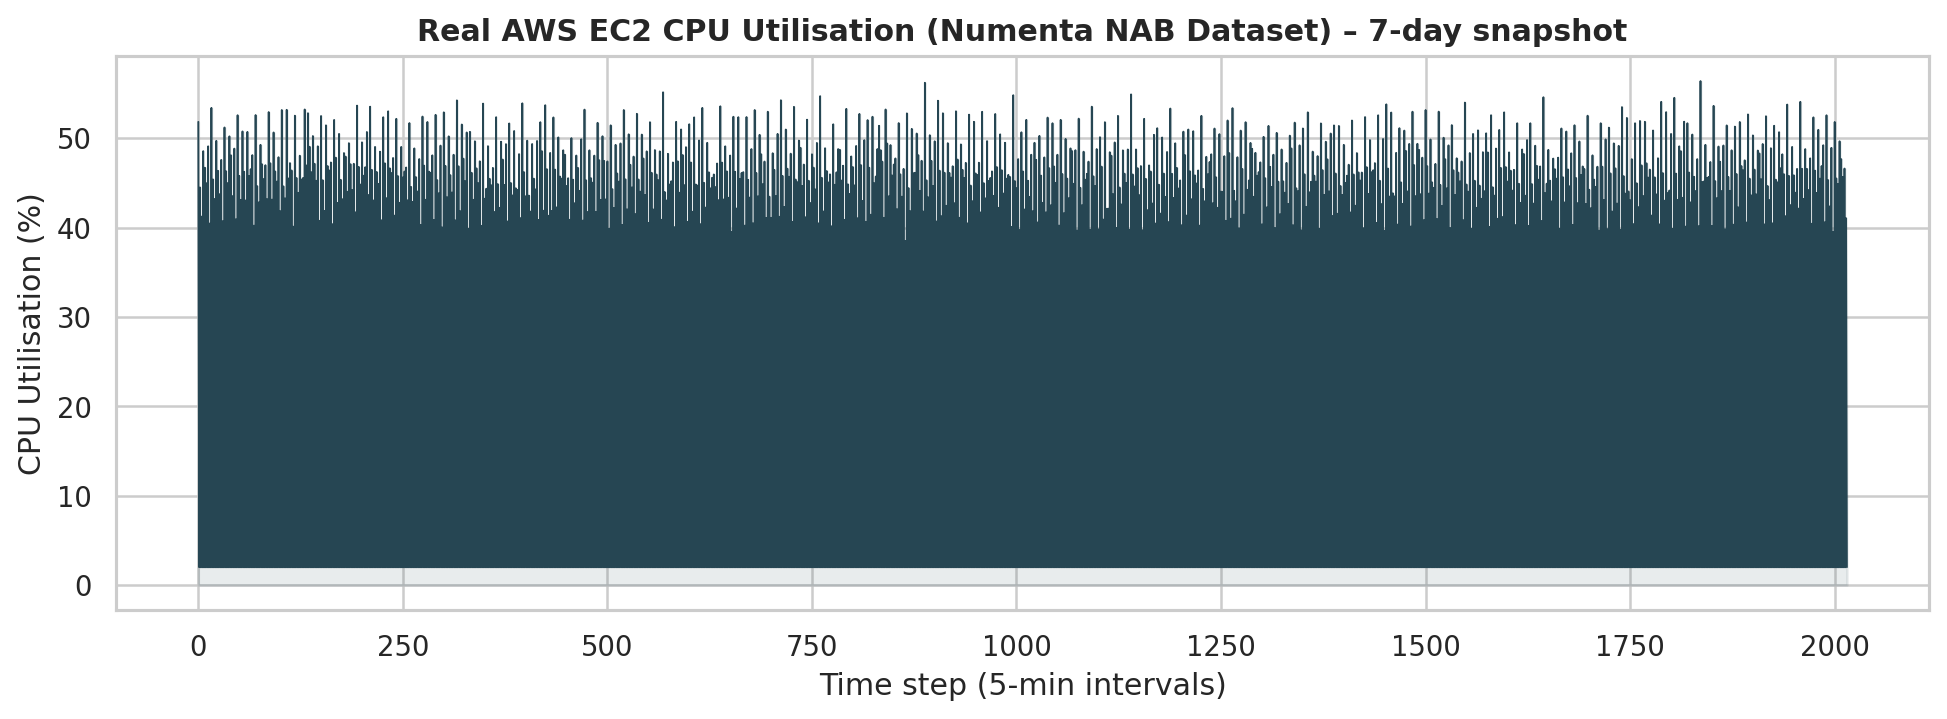

figures/fig2_ceemdan.png


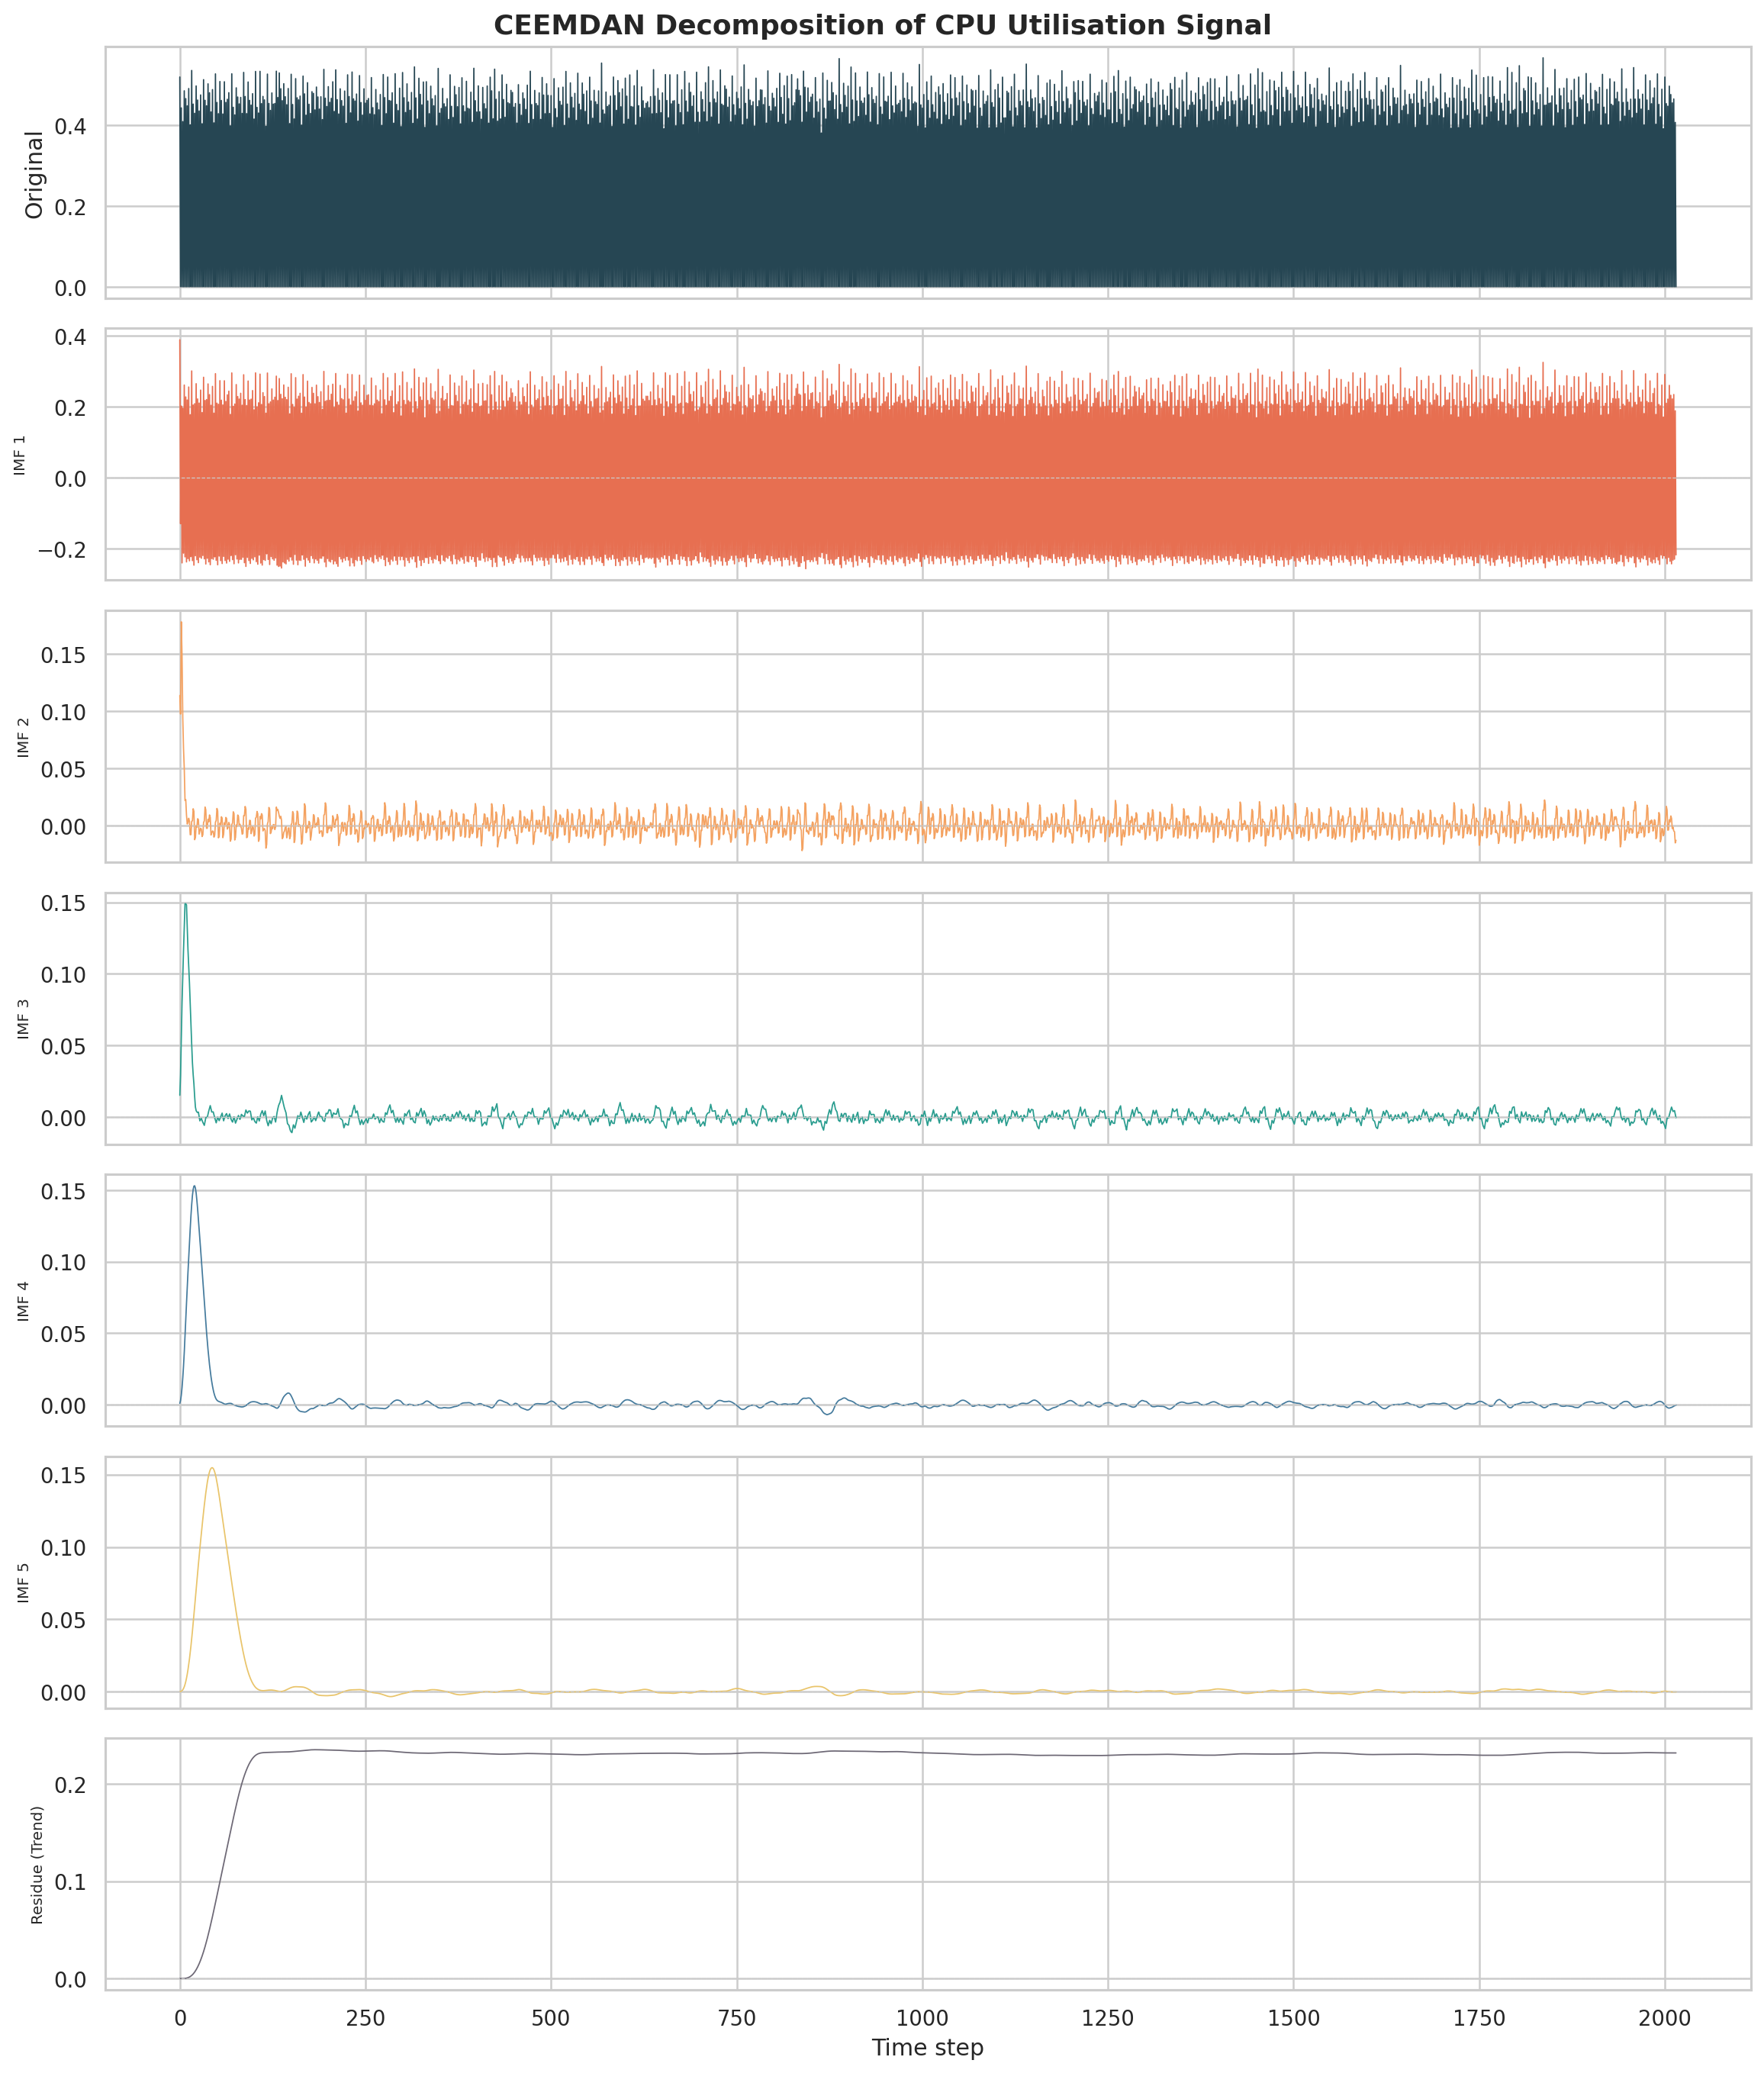

figures/fig3_predictions_overlay.png


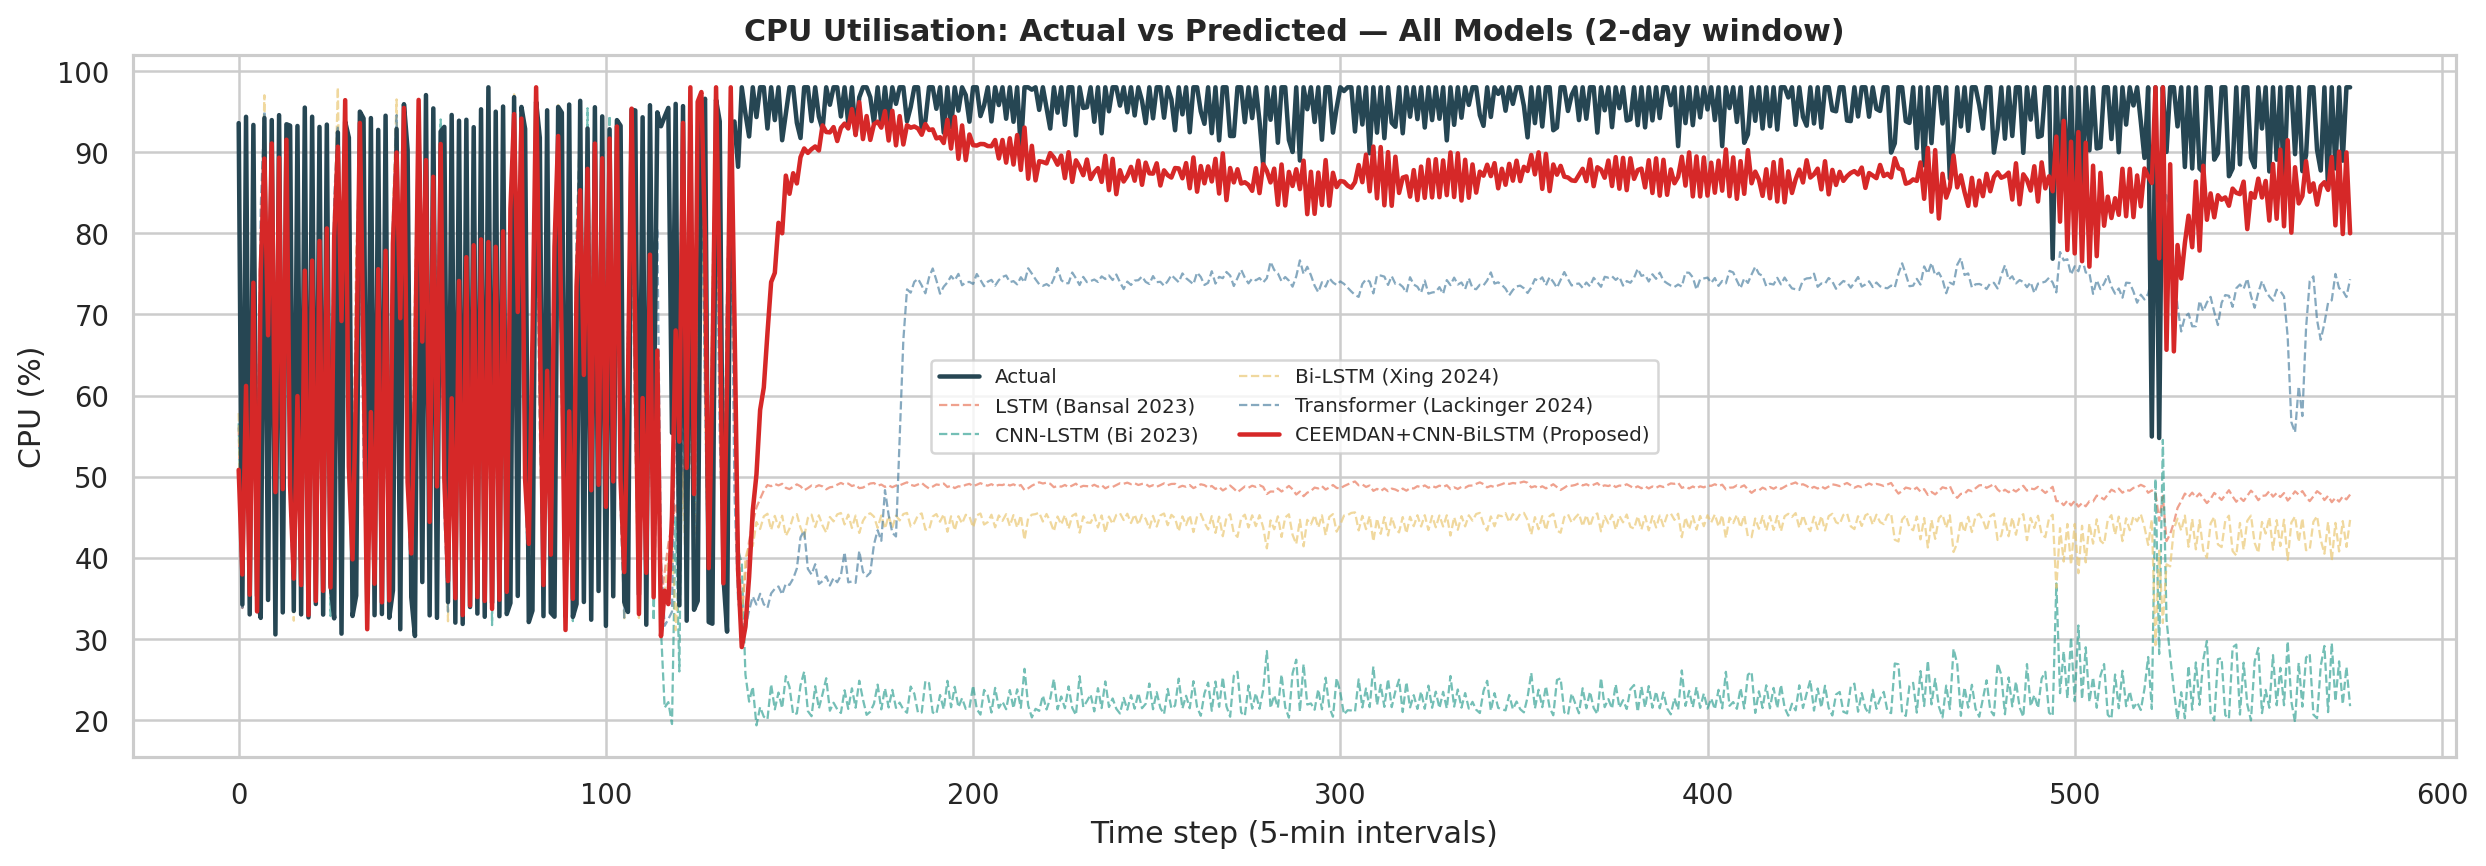

In [15]:
# ── Show figures ───────────────────────────────────────────────────────────
from IPython.display import Image, display
import glob
for fig in sorted(glob.glob('figures/*.png')):
    print(fig)
    display(Image(fig, width=900))

In [16]:
# ── Download results ───────────────────────────────────────────────────────
import shutil
shutil.make_archive('CloudSense_results', 'zip', '.', 'figures')
shutil.copy('results/metrics.csv', 'metrics.csv')
from google.colab import files
files.download('CloudSense_results.zip')
files.download('metrics.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>